In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS
from tqdm import tqdm

import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import get_data, get_n_params, make_pseudo_spacetime_cross_offsets, ModelTimeRecorder, RelativeL2ConvergenceTracker
from model.CaPITN import CaPITN


if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

space_dim = 1
num_space = 3
space_step = 1e-2
num_step = 5
step_size = 1e-4

num_spatial_tokens = 1 + space_dim * (num_space - 1)
patch_length = num_step * num_spatial_tokens
spatial_radius = (num_space // 2) * space_step
c_max = spatial_radius / step_size

patch_offsets = torch.tensor(
    make_pseudo_spacetime_cross_offsets(
        space_dim,
        num_space=num_space,
        space_step=space_step,
        num_step=num_step,
        step=step_size,
    ),
    dtype=torch.float32,
    device=device,
)
assert patch_offsets.shape == (patch_length, space_dim + 1)
assert patch_offsets.dtype == torch.float32
assert patch_offsets.device.type == device.type

In [3]:
res, b_left, b_right, b_upper, b_lower = get_data([-1, 1], [0, 1], 51, 51)
res_test, b_left_test, _, _, _ = get_data([-1, 1], [0, 1], 256, 201)


def build_center(coords):
    coords = np.asarray(coords)
    assert coords.ndim == 2 and coords.shape[1] == space_dim + 1
    center = torch.tensor(coords[:, None, :], dtype=torch.float32, device=device)
    assert center.shape == (coords.shape[0], 1, space_dim + 1)
    return center


res = build_center(res)
b_left = build_center(b_left)
b_right = build_center(b_right)
b_upper = build_center(b_upper)
b_lower = build_center(b_lower)

x_res = res[:, :, 0:1].clone().detach().requires_grad_(True)
t_res = res[:, :, 1:2].clone().detach().requires_grad_(True)
assert x_res.is_leaf and t_res.is_leaf
assert x_res.shape == (res.shape[0], 1, space_dim)
assert t_res.shape == (res.shape[0], 1, 1)

x_left = b_left[:, :, 0:1]
t_left = b_left[:, :, 1:2]
x_right = b_right[:, :, 0:1]
t_right = b_right[:, :, 1:2]
x_upper = b_upper[:, :, 0:1]
t_upper = b_upper[:, :, 1:2]
x_lower = b_lower[:, :, 0:1]
t_lower = b_lower[:, :, 1:2]


def rigid_patch_grad(value, coordinate_center):
    token_grad = torch.autograd.grad(
        value,
        coordinate_center,
        grad_outputs=torch.ones_like(value),
        retain_graph=True,
        create_graph=True,
    )[0]
    return token_grad.sum(dim=1)


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [4]:
from scipy.io import loadmat

mat = loadmat('./kdv_ref.mat')
x_data_base = mat['X_grid'].flatten()[:, None]
t_data_base = mat['T_grid'].flatten()[:, None]
u_data = mat['u_exact'].flatten()[:, None]

data_coords = np.concatenate([x_data_base, t_data_base], axis=-1)
data_center = build_center(data_coords)

x_data = data_center[:, :, 0:1]
t_data = data_center[:, :, 1:2]
u_data = torch.tensor(u_data, dtype=torch.float32, device=device)
assert x_data.shape == (u_data.shape[0], 1, space_dim)
assert t_data.shape == (u_data.shape[0], 1, 1)
assert u_data.shape == (data_coords.shape[0], 1)

In [5]:
model = CaPITN(
    in_dim=2,
    d_model=32,
    n_heads=2,
    d_ff=512,
    n_layers=1,
    out_dim=1,
    c_max=c_max,
).to(device)

model.apply(init_weights)
trainable_parameters = tuple(model.parameters())

optim = torch.optim.LBFGS(trainable_parameters, line_search_fn='strong_wolfe')
print(model)
print(get_n_params(model))

CaPITN(
  (embedding): Linear(in_features=2, out_features=32, bias=True)
  (encoder): Encoder(
    (layers): ModuleList(
      (0): EncoderLayer(
        (attn): CharacteristicAwareAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
          (W_v): Linear(in_features=32, out_features=32, bias=True)
          (W_o): Linear(in_features=32, out_features=32, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): Sequential(
          (0): Linear(in_features=32, out_features=256, bias=True)
          (1): WaveBiasAct()
          (2): Linear(in_features=256, out_features=32, bias=True)
        )
      )
    )
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0): DecoderLayer(
        (attn): CharacteristicAwareAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
  

In [6]:
relative_l2_threshold = 0.1
monitor_reference = u_data.detach().cpu().numpy().reshape(-1, 1)

def get_monitor_prediction():
    with torch.no_grad():
        prediction = model(x_data, t_data, patch_offsets)[:, 0, :]
    return prediction.reshape(-1, 1).cpu().numpy()

convergence_tracker = RelativeL2ConvergenceTracker(
    monitor_reference,
    relative_l2_threshold,
)
convergence_tracker.record(0.0, get_monitor_prediction())


1.7661385947550081

In [ ]:
time_recorder = ModelTimeRecorder(device)
loss_track = []

for i in tqdm(range(500)):
    def closure():
        optim.zero_grad(set_to_none=True)

        u_res = model(x_res, t_res, patch_offsets)[:, 0, :]
        u_upper = model(x_upper, t_upper, patch_offsets)[:, 0, :]
        u_lower = model(x_lower, t_lower, patch_offsets)[:, 0, :]

        u_t = rigid_patch_grad(u_res, t_res)
        u_x = rigid_patch_grad(u_res, x_res)
        u_xx = rigid_patch_grad(u_x, x_res)
        u_xxx = rigid_patch_grad(u_xx, x_res)

        loss_res = torch.mean((u_t + u_res * u_x + 0.0025 * u_xxx) ** 2)
        loss_bc = torch.mean((u_upper - u_lower) ** 2)

        u_data_pred = model(
            x_data,
            t_data,
            patch_offsets,
        )[:, 0, :]
        assert u_data_pred.shape == u_data.shape, (
            f'prediction shape {u_data_pred.shape} does not match target shape {u_data.shape}'
        )
        loss_data = torch.mean((u_data_pred - u_data) ** 2)

        loss = loss_res + loss_bc + loss_data
        if not torch.isfinite(loss).item():
            raise FloatingPointError(f'Non-finite total loss: {loss.item()}')

        loss_track.append([loss_res.item(), loss_bc.item(), loss_data.item()])

        loss.backward(inputs=trainable_parameters)
        return loss

    with time_recorder.record_training():
        optim.step(closure)

    convergence_tracker.record(
        time_recorder.training_time,
        get_monitor_prediction(),
    )

100%|██████████| 500/500 [33:25<00:00,  4.01s/it]


In [8]:
np.save('./results/kdv_loss_capitn.npy', loss_track)
torch.save(model.state_dict(), './results/kdv_capitn.pt')

print('Loss Res: {:4f}, Loss_BC: {:4f}, Loss_Data: {:4f}'.format(loss_track[-1][0], loss_track[-1][1], loss_track[-1][2]))
print('Train Loss: {:4f}'.format(np.sum(loss_track[-1])))

print('Training Time: {:.2f} s'.format(time_recorder.training_time))

np.save(
    './results/kdv_relative_l2_error_vs_training_time_capitn.npy',
    convergence_tracker.as_array(),
)
if convergence_tracker.first_threshold_time is None:
    print('Relative L2 threshold {:.3f} was not reached.'.format(relative_l2_threshold))
else:
    print(
        'Relative L2 threshold {:.3f} first reached at {:.6f} s'.format(
            relative_l2_threshold,
            convergence_tracker.first_threshold_time,
        )
    )


Loss Res: 0.000009, Loss_BC: 0.000001, Loss_Data: 0.000004
Train Loss: 0.000013
Training Time: 1990.39 s
Relative L2 threshold 0.100 first reached at 221.374617 s


Inference Time: 0.027628 s
relative L1 error: 0.002680
relative L2 error: 0.002754


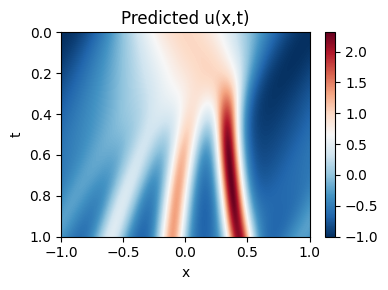

In [9]:
res_test = np.column_stack([
    mat["X_grid"].ravel(),
    mat["T_grid"].ravel(),
])

res_test = build_center(res_test)
x_test, t_test = res_test[:, :, 0:1], res_test[:, :, 1:2]
assert x_test.shape == (res_test.shape[0], 1, space_dim)
assert t_test.shape == (res_test.shape[0], 1, 1)

with time_recorder.record_inference():
    with torch.no_grad():
        pred = model(
            x_test,
            t_test,
            patch_offsets,
        )[:, 0, :]
        pred = pred.cpu().numpy()
print('Inference Time: {:.6f} s'.format(time_recorder.inference_time))

pred = pred.reshape(201, 256)

u = mat['u_exact']

rl1 = np.sum(np.abs(u - pred)) / np.sum(np.abs(u))
rl2 = np.sqrt(np.sum((u - pred) ** 2) / np.sum(u ** 2))

print('relative L1 error: {:4f}'.format(rl1))
print('relative L2 error: {:4f}'.format(rl2))

plt.figure(figsize=(4, 3))
plt.imshow(pred, extent=[-1, 1, 1, 0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_capitn_pred.png')
plt.show()

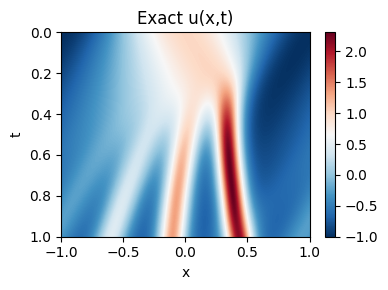

In [10]:
plt.figure(figsize=(4,3))
plt.imshow(u, extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Exact u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_exact.png')
plt.show()

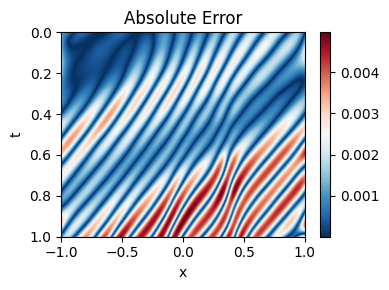

In [11]:
plt.figure(figsize=(4,3))
plt.imshow(np.abs(pred - u), extent=[-1,1,1,0], aspect='auto', cmap='RdBu_r')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/kdv_capitn_error.png')
plt.show()

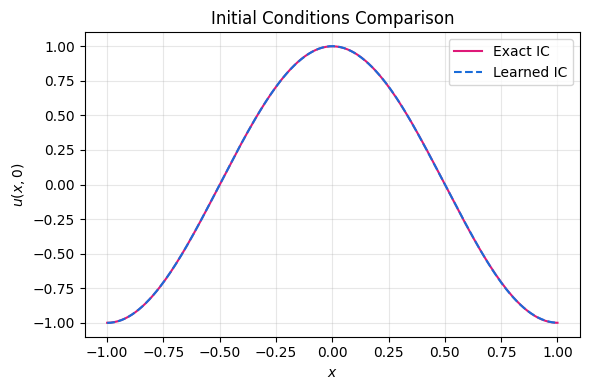

In [12]:
x0_ini = b_left_test[:, 0:1].flatten()
u0_ini = np.cos(np.pi * x0_ini).flatten()
b_left_test_center = build_center(b_left_test)

with torch.no_grad():
    u0_inverse = model(
        b_left_test_center[:, :, 0:1],
        b_left_test_center[:, :, 1:2],
        patch_offsets,
    )[:, 0, :]
    u0_inverse = u0_inverse.cpu().numpy().flatten()

np.save('./results/kdv_u0_inverse_capitn.npy', u0_inverse)

plt.figure(figsize=(6, 4))
plt.plot(x0_ini, u0_ini, label='Exact IC', color='#de1978')
plt.plot(x0_ini, u0_inverse, label='Learned IC', color='#196cd9', linestyle='--')

plt.xlabel('$x$')
plt.ylabel('$u(x,0)$')
plt.title('Initial Conditions Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./results/kdv_capitn_ini.png')
plt.show()

In [13]:

rel_error_ini_l1 = np.linalg.norm(u0_ini - u0_inverse, 1) / np.linalg.norm(u0_ini, 1)
rel_error_ini_l2 = np.linalg.norm(u0_ini - u0_inverse, 2) / np.linalg.norm(u0_ini, 2)
print('Relative L1 Error of Initial Condition: {:4f}'.format(rel_error_ini_l1))
print('Relative L2 Error of Initial Condition: {:4f}'.format(rel_error_ini_l2))



Relative L1 Error of Initial Condition: 0.001145
Relative L2 Error of Initial Condition: 0.001340
